# Stimulus evidence

In [1]:
import remeta
%load_ext autoreload
%autoreload 2

ReMeta is designed to work with continuous stimulus magnitudes, corresponding to the absolute value of the `stimuli` variable passed to ReMeta's fit methods.

An important assumption in this regard is that the stimulus magnitude encodes the amount of *evidence* available — *in interval scale*.

*Evidence* means that the stimulus magnitude is proportional to a signal-to-noise ratio. Since proportionality is sufficient, stimulus magnitude can also simply encode the "signal numerator" (e.g., offset angle from a reference, motion coherence in percent) IF the noise is not altered between different signal levels.

*Interval scale* means that 1) identical increments of the stimulus variable anywhere along the stimulus axis should correspond to identical increments in evidence; and 2), the value 0 should indicate the absence of any evidence.

If you are uncertain whether your stimuli conform to this requirement, ReMeta offers the method `remeta.check_linearity()`.

```python

# load `stimuli` and `choices`; optionally `difficulty_levels` if stimuli is
# categorical and the difficulty is available in a separatey array.

remeta.check_linearity(stimuli, choices[, difficulty_levels])

```

Below is an example of a dataset on which this method was evoked. Note that we pass the entire group's data to `check_linearity`.

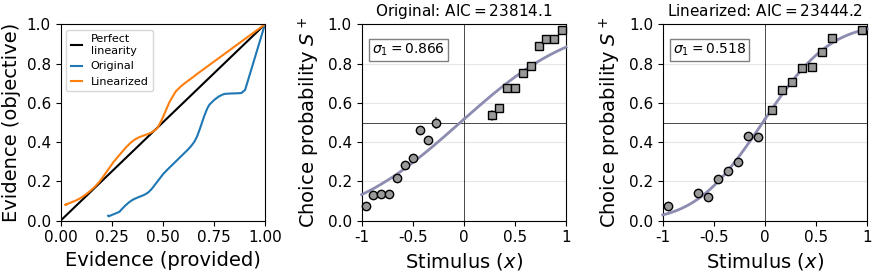

In [2]:
from IPython.display import Image, display
display(Image(filename='img/linearization_example.png'))

Linearization works by estimating type 1 noise ($\sigma_1$) along the stimulus magnitude dimension while setting the "signal" to 1 in each case. The original stimuli are then transformed to a signed signal-to-noise ratio
in the form $1/\sigma_1$.

The left panel shows the relationship between the originally provided stimulus evidence and objective stimulus evidence (blue line). The mismatch is quite evident in this example and a psychometric probit curve hardly fits the data (center panel).

After linearization, provided and objective evidence line up much better (orange line in the left panel) and the fit is visually and objectively better (right panel).

Note however, that the `remeta.check_linearity()` method uses – by default – a computationally cheap method to correct for linearity. To thoroughly linearize stimuli, use `remeta.linearize_stimulus_evidence()`:

```python
stimuli_linear = remeta.linearize_stimulus_evidence(stimuli, choices[, difficulty_levels])
```

Again, we recommend to pass the entire group's data to `linearize_stimulus_evidence`, either as a flat 1d array or as a `n_subjects` x `n_trials` 2d array. The default settings usually work fine – if not, check out the parameters of this method.

To control the success of linearization, pass the new `stimuli` variable again to `remeta.check_linearity()`:

```python
remeta.check_linearity(stimuli_linear, choices)
```

Not that `stimuli_linear` now encodes stimulus category *and* magnitude and thus `difficulty_levels` are definitely not required.

In the example, this is the result:

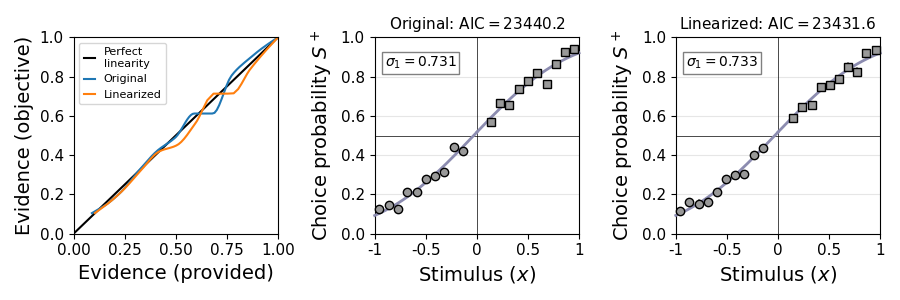

In [4]:
from IPython.display import Image, display
display(Image(filename='img/linearization_example_after.png'))

The `stimuli` variable is now almost perfectly linear. The model fit is even a bit better compared to the initial check above, because `remeta.linearize_stimulus_evidence()` transforms the magnitude axis (by default) with a computationally more elaborate method involving a rolling window.

**Important note:** Linearizing the stimulus variable like this may feel like cheating and in some sense it is. The fit of the type 1 model will be trivially better if the stimulus variable was first transformed by an identical type 1 model. Indeed, following such preprocessing, the single-subject AIC / BIC values of ReMeta models cannot (easily) be compared to other models, as some parameters were used during preprocessing, even if only at the group level.

The advantage of careful linearization – as outlined above – is that it likely improves parameter estimates across both the type 1 and type 2 stage. At the type 1 stage, $\sigma_1$ / `type1_noise` now provides a single and robust estimate of an observer's overall sensitivity, independent of stimulus difficulty levels. At the type 2 stage, forwarded type 1 decision values are more precise and provide a better basis for type 2 parameter inference.

It can be thus a trade-off between (likely) better parameter inference and AIC / BIC values that can be compared to other models. If you do care about model comparison, your options are to either i) do stimulus linearization based on an independent dataset (or pilot subjects / excluded subjects), ii) _not use_ this linearization method and instead provide stimulus magnitude in a form that approximates a signal-to-noise ratio (using knowledge about the process of stimulus generation), or iii) just not care about linearization at all.

The alternative – adopted by most other models – is to estimate a sensitivity parameter for each participant and each difficulty level separately. While this allows for the computation of a clean per-participant likelihood, it comes with disadvantages:
1. Sensitivity estimated in this way conflates the difficulty of the stimulus and the specific sensitivity of the participant.
2. It requires enough samples per participant and difficulty level, as otherwise parameter fits become quickly unstable.
3. It is unclear how to fit these models if stimulus evidence is continuous and not restricted to a few discrete evidence levels.
